# Dash Basics: HTML and Core Components

### Objectives
- Create a dash application layout
- Add HTML H1 (Header), P (Paragraph), and Div (Divider) components
- Add core graph component
- Add multiple charts

### Dataset Used
[Airline Reporting Carrier On-Time Performance](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DV0101EN-SkillsNetwork/Data%20Files/airline_data.csv)

### Goal
To create a dashboard that displays the percentage of flights under a specific distance group. A distance group is a 250-mile interval of distance. Hence, a flight that covers under 250 miles of distance is in the 1st distance group, a flight that covers between 250 to 500 miles is in the second group, and so on.

### Expected Output
The dashboard should consist of the following components:
- A title in HTML header format
- A dashboard description in (I think) red font.
- The graph itself.
![Expected Output](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DV0101EN-SkillsNetwork/labs/Module%204/images/basics_output.png)

### To do
1. Import required libraries and read the dataset
2. Create an application layout
3. Add title to the dashboard using HTML H1 element
4. Add a paragraph about the chart using HTML P element (I think we will use this for creating the description)
5. Add the pie chart above using core graph component
6. Run the app
---

## Task 1 - Data Preparation
The packages needed for this one are:
- **Pandas** to read the dataset in csv format and store it in a DataFrame
- **Plotly Express** to build any interactive graphs.
- **Dash** - In particular, we need the dash `html` module for formatting text in html and the dash `dcc` (Dash Core Components) module for rendering the interactive graphs.

In [22]:
# Import required packages
import pandas as pd
import plotly.express as px
from dash import Dash, html, dcc

To import the dataset, we'll use the `pandas.read_csv()` method.

In [48]:
csv_path = "/".join(['https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud',
                'IBMDeveloperSkillsNetwork-DV0101EN-SkillsNetwork/Data%20Files/airline_data.csv'])
airline_data = pd.read_csv(csv_path)
airline_data.head()

,Unnamed: 0,Year,Quarter,Month,DayofMonth,DayOfWeek,FlightDate,Reporting_Airline,DOT_ID_Reporting_Airline,IATA_CODE_Reporting_Airline,...,Div4WheelsOff,Div4TailNum,Div5Airport,Div5AirportID,Div5AirportSeqID,Div5WheelsOn,Div5TotalGTime,Div5LongestGTime,Div5WheelsOff,Div5TailNum
0,1295781,1998,2,4,2,4,1998-04-02,AS,19930,AS,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1125375,2013,2,5,13,1,2013-05-13,EV,20366,EV,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,118824,1993,3,9,25,6,1993-09-25,UA,19977,UA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,634825,1994,4,11,12,6,1994-11-12,HP,19991,HP,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1888125,2017,3,8,17,4,2017-08-17,UA,19977,UA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Based on the features of the dataset, which can be viewed by visiting the link https://www.transtats.bts.gov/Fields.asp?gnoyr_VQ=FGJ, we have the column: `DistanceGroup` which is desribed as the "Distance Intervals, every 250 Miles, for Flight Segment" and `Flights` which is the number of flights.

Furthermore, since the data for the proportion of flights under distance group will be visualized by a pie chart, we only need `DistanceGroup` and `Flights`. In the `plotly.express.pie()` method, `DistanceGroup` will be the names while the counts of `Flights` in each distance group will be the values.

In [51]:
airline_data_dgf = airline_data[['DistanceGroup','Flights']]
airline_data_dgf.head()

,DistanceGroup,Flights
0,1,1.0
1,2,1.0
2,1,1.0
3,2,1.0
4,3,1.0


The pie chart can then be created using `plotly.express`.

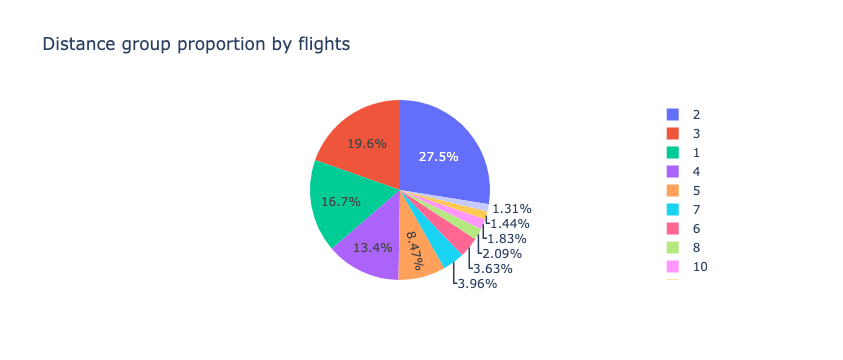

In [52]:
fig = px.pie(airline_data_dgf,
             names='DistanceGroup',
             values='Flights',
             title='Distance group proportion by flights')
fig.show()

## Task 2 - Create dash application and get the layout skeleton

The structure for this app is as follows:
1. Initializing the app using the `Dash()` constructor
2. The app layout -- in this case, the layout consists of the Title, description, and the pie chart. To do this, we construct a list of the HTML components `H1`, `P`, and the pie chart, and then assign the list to the `app.layout` attribute.
3. Running the app. In most of the examples I've encountered, the app is ran with the following code:
```
if __name__ == '__main__':
    app.run(debug=True)
```

In [54]:
#Initialize the app
app = Dash()

Next is to write the layout skeleton. It is the same as writing in HTML except that we write it as a list where the items are the components of the HTML document. And instead of `<Component>...</Component>`, we use `html.Component()`

In [ ]:
#App layout
app.layout = [html.H1(....),
              html.P(....),
              dcc.Graph(....)]

`html.H1(....)` is for the title, `html.P(....)` for the description, and we include the pie chart in the layout using the `dcc.Graph()` method from the `dcc` module. The placeholders `....` will be replaced by the corresponding content.

## Task 3 - Add the application title
Along with the text, `html.H1` has other parameters that we can define such as `style` which is a dictionary containing keys such as `color`, `fontSize`, and `textAlign`. We will use this for the title of the dashboard.

In [82]:
Title = html.H1('Airline Dashboard',
               style={'color': '#503D36',
                     'font-size': 40,
                     'textAlign': 'center'})

## Task 4 - Add the application description
Similar to `html.H1`, the component `html.P` also has the parameter `style`. We will use this in creating the description for the dashboard.

In [83]:
Description = html.P('Proportion of distance group (250 mile distance interval group) by flights',
                     style={'textAlign':'center',
                            'color': '#F57241'})

## Task 5 - Update the graph
We then assign the list containing all the components to the `app.layout` attribute. The pie chart is included in the list by passing it to the `dcc.Graph()` method.

In [84]:
app.layout = [Title,
              Description,
              dcc.Graph(figure=fig)]

## Task 6 - Run the application
Finally, we run the application.

In [86]:
if __name__ == '__main__':
    app.run()